# Final Project
**Team Members:** Dipesh Ghimire, Charles Benello, Wan Hwang

**Course:** FINM 33160 1 (Winter 2026) Machine Learning for Finance

In [1]:
import warnings

import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import optuna
from optuna.samplers import TPESampler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

## Loading the Cleaned CRSP Monthly Parquet File
We load the cleaned data from `data/crsp_monthly.parquet`. This Parquet file is produced by running the data cleaning pipeline in `csv_to_parquet.py`, which standardizes column names, sorts by identifier and date, converts data types, removes zero or negative prices, and ensures return values are valid for analysis.

In [2]:
# Load the CRSP monthly parquet file
crsp_monthly = pd.read_parquet("data/crsp_monthly.parquet")
crsp_monthly.sort_values(by= ['date', 'permno'], inplace=True)

# Display the first 10 rows of the dataset
display(crsp_monthly.head(10).style.set_caption("CRSP Monthly Data - First 10 Rows"))

,permno,date,shrcd,siccd,ticker,comnam,prc,ret,shrout
901,10006,1926-01-30 00:00:00,10.000000,3740,nan,AMERICAN CAR & FDRY CO,110.250000,0.032732,600.000000
3700,10022,1926-01-30 00:00:00,10.000000,3420,nan,AMERICAN SAFETY RAZOR CORP,57.000000,0.017857,200.000000
5587,10030,1926-01-30 00:00:00,10.000000,3310,nan,AMERICAN BRAKE SHOE & FDRY,174.250000,0.161667,156.000000
8811,10049,1926-01-30 00:00:00,12.000000,2640,nan,ABITIBI POWER & PAPER LTD,83.500000,0.141892,250.000000
9802,10057,1926-01-30 00:00:00,11.000000,3540,nan,NATIONAL ACME CO,11.812500,-0.035714,500.000000
11451,10065,1926-01-30 00:00:00,14.000000,4710,nan,ADAMS EXPRESS CO,104.500000,-0.027907,120.000000
13089,10073,1926-01-30 00:00:00,10.000000,3520,nan,ADVANCE RUMELY CO,18.375000,0.050000,138.000000
14311,10081,1926-01-30 00:00:00,10.000000,1000,nan,AHUMADA LEAD CO,8.250000,-0.083333,1192.000000
16711,10102,1926-01-30 00:00:00,10.000000,2810,nan,AIR REDUCTION INC,110.000000,0.002278,201.000000
18826,10110,1926-01-30 00:00:00,10.000000,3010,nan,AJAX RUBR INC,10.625000,0.011905,500.000000


In [3]:
# Subset the dataset for common stock (shrcd = 10, 11 and 12)
crsp_monthly = crsp_monthly[crsp_monthly['shrcd'].isin([10, 11, 12])]

## Feature Engineering

##### Cross-Sectional Price-Based Features Identified as Anomalies in Finance Literature

In this project, we construct a set of cross-sectional features derived from asset prices, all of which have been documented as anomalies in the academic finance literature. Each feature is motivated by an economic hypothesis about asset pricing, and we cite the relevant papers justifying its use.

---

### 1) **Momentum (3M, 6M, 9M, and 12-1M "Classic" Lookback)**

**Economic Hypothesis:**  
The momentum anomaly refers to the empirical tendency for stocks that have performed well in the past to continue to perform well in the near future, and vice versa for poorly performing stocks. This is commonly explained by the *underreaction hypothesis* (Jegadeesh & Titman, 1993), which posits that investors are slow to incorporate new information, causing positive (or negative) trends to persist over intermediate horizons.

**Implementation:**  
We compute cumulative returns over different lookback periods: 3 months, 6 months, 9 months, and the classic 12-month lookback skipping the most recent month. ~ *Jegadeesh & Titman (1993): "Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency (JFE)"*).

---

### 2) **Mean Reversion ("Short-Term Reversal")**

**Economic Hypothesis:**  
Stocks that performed poorly in the previous month tend to outperform in the following month, and vice versa. This short-term reversal is commonly attributed to overreaction by investors and temporary liquidity shocks. (*Jegadeesh, 1990: "Evidence of Predictable Behavior of Security Returns"*).

**Implementation:**  
We create a one-month lagged return ("1M momentum") feature to quantify this mean reversion effect.

---

### 3) **Price Bins (Lagged Price Discretization)**

**Economic Hypothesis:**  
Empirical studies have found that low-priced stocks, when sorted into bins by share price, tend to yield higher cross-sectional average returns than high-priced stocks. One hypothesis is that price may serve as a proxy for mispricing or neglected risk. For example, *Asness, Frazzini, Israel, & Moskowitz (2015): "Fact, Fiction, and Value Investing"* discusses discrete price effects, and *Birru & Wang (2016): "Nominal Prices Matter"* specifically notes that lower-priced stocks earn higher returns due to investor biases and constraints related to nominal pricing.

**Implementation:**  
We discretize lagged prices (e.g., price at t-1) into bins and use them as categorical features.

---

### 4) **Log Market Capitalization (Log MktCap = log(shrout × prc))**

**Economic Hypothesis:**  
The *size effect* refers to the observation that small-capitalization firms (i.e., those with lower market capitalization) tend to outperform large-cap firms on a risk-adjusted basis. This anomaly is well-documented in the literature, particularly in *Banz (1981): "The Relationship Between Return and Market Value of Common Stocks"* and *Fama & French (1993): "Common Risk Factors in the Returns on Stocks and Bonds"*.

**Implementation:**  
We compute the log of market capitalization for each stock as log(shares outstanding × price).

---

### 5) **Seasonality in the Cross Section ("Return Seasonality" / Calendar-Time Effects)**
 
**Economic Hypothesis:**  
Seasonality in the cross section refers to the well-documented finding that a stock’s return from one year ago (lag 12 months), two years ago (24 months), and even three years ago (36 months) can positively predict its return today, i.e., stocks that outperformed in a given month one, two, or three years earlier tend to outperform contemporaneously. This seasonal pattern is interpreted as evidence of periodic behavioral biases or institutional frictions that repeat on an annual cycle. Notably, Heston and Sadka (2008) provide strong empirical evidence for this phenomenon.
 
**Implementation:**  
We create features for each stock’s return lagged exactly 12, 24, and 36 months, respectively. These lagged monthly returns are commonly named “12M seasonality”, “24M seasonality”, and “36M seasonality” features, following the methodology of Heston & Sadka (2008).

---

### 6) **Interaction Effects**
 
**Economic Hypothesis:**  
The interaction between the above features may capture additional non-linearities in returns that are missed by modeling each anomaly in isolation. For example, momentum may be stronger in small cap stocks, or the price effect may be conditional on recent returns (*Daniel & Titman, 1997: "Evidence on the Characteristics of Cross Sectional Variation in Stock Returns"*). Including interaction terms allows us to empirically test for such joint effects documented in the literature.

---
 
**References:**
- Jegadeesh, N., & Titman, S. (1993). Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency. *Journal of Finance, 48*(1), 65-91.
- Jegadeesh, N. (1990). Evidence of Predictable Behavior of Security Returns. *Journal of Finance, 45*(3), 881-898.
- Birru, J., & Wang, B. (2016). Nominal Prices Matter. *Review of Financial Studies, 29*(4), 976–1010.
- Banz, Rolf W. (1981). The Relationship Between Return and Market Value of Common Stocks. *Journal of Financial Economics, 9*(1), 3–18.
- Fama, E. F., & French, K. R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics, 33*(1), 3-56.
- Asness, C. S., Frazzini, A., Israel, R., & Moskowitz, T. J. (2015). Fact, Fiction, and Value Investing. *Journal of Portfolio Management, 42*(1), 34-52.
- Daniel, K. & Titman, S. (1997). Evidence on the Characteristics of Cross Sectional Variation in Stock Returns. *Journal of Finance, 52*(1), 1–33.
- Heston, S. L., & Sadka, R. (2008). Seasonality in the Cross-Section of Stock Returns. *Journal of Financial Economics, 87*(2), 418-445.


In [4]:
# 1) Price Momentum Based Features
crsp_monthly['12m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(12).mean().shift(2))
crsp_monthly['9m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(9).mean().shift(2))
crsp_monthly['6m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(6).mean().shift(2))
crsp_monthly['3m_momentum'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.rolling(3).mean().shift(2))

In [5]:
# 2) Mean Reversion Based Features
crsp_monthly['1m_mean_reversion'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(1))

In [6]:
# 3) Price Bins Based Features
crsp_monthly['lag_prc'] = crsp_monthly.groupby('permno')['prc'].shift(1)
crsp_monthly.dropna(subset=['lag_prc'], inplace=True)

crsp_monthly['lag_prc_bin'] = crsp_monthly.groupby('date')['lag_prc'].transform(lambda x: pd.qcut(x, q=5, labels=False))

In [7]:
# 4) Log Market Capitalization Based Features
crsp_monthly['log_mktcap'] = np.log(crsp_monthly['shrout'] * crsp_monthly['prc'])
crsp_monthly['log_mktcap'] = crsp_monthly.groupby('permno')['log_mktcap'].transform(lambda x: x.shift(1))
crsp_monthly.dropna(subset=['log_mktcap'], inplace=True)

In [8]:
# 5) Seasonality Based Features
crsp_monthly['12m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(12))
crsp_monthly['24m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(24))
crsp_monthly['36m_seasonality'] = crsp_monthly.groupby('permno')['ret'].transform(lambda x: x.shift(36))

In [9]:
# 6) Features Capturing Interaction Effects

## Lagged Prices and Momentum
crsp_monthly['interaction_12m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['12m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_9m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['9m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_6m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['6m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_3m_momentum_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['3m_momentum'].transform(lambda x: (x - x.mean()) / x.std())

## Lagged Prices and Mean Reversion
crsp_monthly['interaction_1m_mean_reversion_lag_prc'] = crsp_monthly.groupby(['date', 'lag_prc_bin'])['1m_mean_reversion'].transform(lambda x: (x - x.mean()) / x.std())

## Log Market Capitalization and Momentum
crsp_monthly['log_mktcap_bin'] = crsp_monthly.groupby('date')['log_mktcap'].transform(lambda x: pd.qcut(x, q=5, labels=False))
crsp_monthly['interaction_log_mktcap_bin_12m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['12m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_9m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['9m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_6m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['6m_momentum'].transform(lambda x: (x - x.mean()) / x.std())
crsp_monthly['interaction_log_mktcap_bin_3m_momentum'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['3m_momentum'].transform(lambda x: (x - x.mean()) / x.std())

## Log Market Capitalization and Mean Reversion
crsp_monthly['interaction_log_mktcap_bin_1m_mean_reversion'] = crsp_monthly.groupby(['date', 'log_mktcap_bin'])['1m_mean_reversion'].transform(lambda x: (x - x.mean()) / x.std())

## Select Required Columns

In [10]:
# Select only the required columns
columns_to_drop = ['shrcd', 'siccd', 'ticker', 'comnam', 'prc', 'shrout', 'lag_prc', 'log_mktcap_bin']
crsp_monthly.drop(columns=columns_to_drop, inplace=True)

# Set the date column as the index
crsp_monthly.set_index('date', inplace=True)

# Drop rows with missing values
crsp_monthly.dropna(inplace=True)

## Create Target for Regression Model

The regression target is created as a cross-sectional winsorized z-score of **month \(t\)** realized returns (CRSP `ret`).

- For each month \(t\), we take the cross section of stock returns \(r_{i,t}\), winsorize extreme values (0.5th and 99.5th percentiles), and then compute a z-score by subtracting the cross-sectional mean and dividing by the cross-sectional standard deviation.
- Although the target is \(r_t\) (same-row return), our predictors are constructed using only information available by the end of **month \(t-1\)** (via lags / skip-month conventions). Therefore, the model represents a one-month-ahead forecasting setup without look-ahead bias.

This normalization makes the target more robust to outliers and comparable across time.

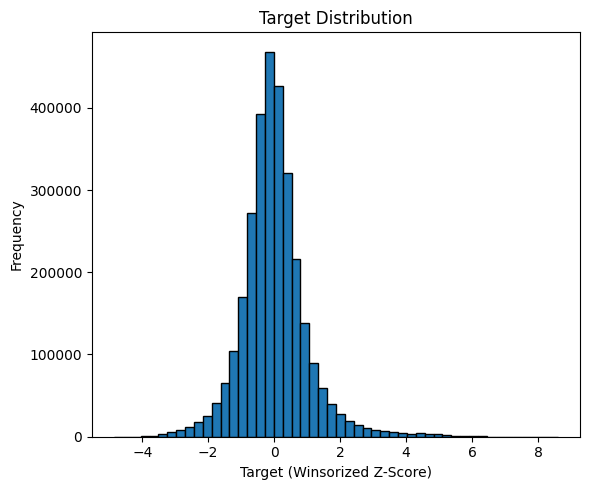

In [11]:
def cs_winsorized_z(x, lower=0.005, upper=0.995):
    lo, hi = x.quantile([lower, upper])
    x_clip = x.clip(lo, hi)
    return (x_clip - x_clip.mean()) / x_clip.std()

crsp_monthly['target'] = crsp_monthly.groupby('date')['ret'].transform(cs_winsorized_z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(crsp_monthly['target'], bins=50, edgecolor='black')
ax.set_title('Target Distribution')
ax.set_xlabel('Target (Winsorized Z-Score)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Prepare Train, Validation, and Test Set
### Methodology (Train / Validate / Refit / Test)
We follow a standard out-of-sample (OOS) evaluation workflow designed to prevent information leakage from the test period into model selection.

#### 1) Chronological split (to avoid look-ahead bias)
Because the data are indexed by time, we split the sample by date:

- **Training set (2000-01-01 to 2009-12-31)**: fit candidate models.
- **Validation set (2010-01-01 to 2014-12-31)**: tune hyperparameters and select the best-performing model configuration.
- **Test set (2015-01-01 onward)**: held out and used only for the final OOS evaluation.

#### 2) Hyperparameter tuning and model selection (validation only)
For each model class and hyperparameter setting, we train on the **training set** and evaluate performance on the **validation set** using the chosen metric(s). We then select the model + hyperparameters that perform best on validation.

#### 3) Final refit on development data (Train + Validation = Pretest Set)
After selecting the best model and hyperparameters, we refit the chosen model on the combined **pretest set**:

- **Pretest Set = Train + Validation (2000-01-01 to 2015-01-01)**

This uses all available pre-test data for parameter estimation while keeping the test set untouched.

#### 4) Out-of-sample prediction and evaluation (test set)
Finally, we generate predictions on the **test set** and report OOS performance. Since the test set was not used for tuning or selection, this provides an unbiased estimate of performance on unseen data.

In [12]:
# 2000-01-01 to 2010-01-01: Train Set
train_set_data = crsp_monthly.loc[(crsp_monthly.index > '2000-01-01') & (crsp_monthly.index < '2010-01-01')]
train_X = train_set_data.drop(columns=['permno', 'ret', 'target'])
train_y = train_set_data['target']

# 2010-01-01 to 2015-01-01: Validation Set
val_set_data = crsp_monthly.loc[(crsp_monthly.index > '2010-01-01') & (crsp_monthly.index < '2015-01-01')]
val_X = val_set_data.drop(columns=['permno', 'ret', 'target'])
val_y = val_set_data['target']

# 2000-01-01 to 2015-01-01: Pretest Set
pretest_set_data = crsp_monthly.loc[(crsp_monthly.index > '2000-01-01') & (crsp_monthly.index < '2015-01-01')]
pretest_X = pretest_set_data.drop(columns=['permno', 'ret', 'target'])
pretest_y = pretest_set_data['target']

# 2015-01-01 to 2020-01-01: Test Set
test_set_data = crsp_monthly.loc[(crsp_monthly.index > '2015-01-01')]
test_X = test_set_data.drop(columns=['permno', 'ret', 'target'])

# Extract validation returns and dates for evaluation
val_realized_ret = val_set_data["ret"].values
val_dates = val_set_data.index.copy()

## Tuning and Model Selection
In this section, we train and tune several candidate models on the training sample using **Optuna** for hyperparameter optimization and evaluate them on the validation sample.

### Model Selection Metric: Rank IC Information Ratio
Our model-selection metric is based on **cross-sectional Rank IC**:
- For each month in the validation set, we compute the Spearman rank correlation between model predictions and realized returns `ret` (NOT the winsorized target).
- We then summarize the monthly Rank IC series using:
  - **Mean Rank IC**: Average predictive power
  - **Standard Deviation of Rank IC**: Stability over time
  - **Information Ratio (ICIR)**: `mean / std`

The **ICIR** is our primary optimization objective as it rewards models that are both predictive and stable over time.

### Candidate Models
We will tune the following models using Optuna:
1. **Decision Tree**
2. **Random Forest**
3. **Extra Trees**
4. **AdaBoost**
5. **LightGBM**
6. **XGBoost**
7. **CatBoost**
8. **Neural Network** (requires feature standardization)
9. **Ensemble Model** (equal-weight average of all tuned models)

### Important Notes
- **Target for Training**: Models are trained on the winsorized z-score `target`
- **Target for Evaluation**: Rank IC is computed against actual returns `ret` for economic interpretability
- **Standardization**: Only Neural Network requires feature standardization (fit on train, transform on validation)
- **Optuna**: We use Bayesian optimization for efficient hyperparameter search

### Rank IC Evaluation Function

We define a function to compute the monthly cross-sectional Rank IC and return the Information Ratio (mean/std) which will be our optimization objective.

In [13]:
def compute_monthly_rank_ic(predictions, realized_returns, dates):
    """
    Compute monthly cross-sectional Spearman rank correlations between
    predictions and realized returns.
    
    Parameters
    ----------
    predictions : array-like
        Model predictions for each observation in the validation set.
    realized_returns : array-like
        Realized CRSP returns ('ret') for each observation in the same rows.
    dates : array-like
        Date index identifying the cross section for each row.
    
    Returns
    -------
    pd.Series
        Monthly Rank IC series indexed by date.
    """
    eval_df = pd.DataFrame({
        "date": pd.to_datetime(dates),
        "pred": np.asarray(predictions, dtype=float),
        "ret": np.asarray(realized_returns, dtype=float),
    })
    
    def _one_month_ic(g):
        # Need at least a few names and non-constant series
        g = g.dropna(subset=["pred", "ret"])
        if len(g) < 3:
            return np.nan
        if g["pred"].nunique() < 2 or g["ret"].nunique() < 2:
            return np.nan
        ic, _ = spearmanr(g["pred"], g["ret"])
        return ic
    
    monthly_ic = eval_df.groupby("date", sort=True).apply(_one_month_ic)
    monthly_ic.name = "rank_ic"
    return monthly_ic

def summarize_rank_ic(monthly_ic):
    """
    Summarize monthly Rank IC series.
    """
    monthly_ic = monthly_ic.dropna()
    mean_ic = monthly_ic.mean()
    std_ic = monthly_ic.std(ddof=1)
    n_months = monthly_ic.shape[0]
    
    if pd.isna(std_ic) or std_ic == 0:
        icir = np.nan
    else:
        icir = mean_ic / std_ic
    
    return {
        "n_months": n_months,
        "mean_rank_ic": mean_ic,
        "std_rank_ic": std_ic,
        "rank_ic_ir": icir,
    }

def evaluate_predictions(predictions, realized_returns, dates):
    """
    Convenience wrapper: prediction vector -> monthly IC series + summary dict.
    """
    monthly_ic = compute_monthly_rank_ic(
        predictions=predictions,
        realized_returns=realized_returns,
        dates=dates,
    )
    summary = summarize_rank_ic(monthly_ic)
    return monthly_ic, summary

### Optuna Configuration and Neural Network Scaler

We set up the Optuna configuration and prepare the standardizer for Neural Network (fit on train, transform on validation).

In [14]:
RANDOM_STATE = 42
N_TRIALS = 200  # Number of Optuna trials per model

# Store results for each model
tuning_results = {}
best_models = {}
best_val_predictions = {}
best_monthly_ic_series = {}

# Standardizer for Neural Network (fit on train, transform on val)
nn_scaler = StandardScaler()
train_X_nn = nn_scaler.fit_transform(train_X)
val_X_nn = nn_scaler.transform(val_X)

### Optuna Objective Functions for Each Model

We define an Optuna objective function for each model class. Each function:
1. Suggests hyperparameters using Optuna's suggest methods
2. Creates and trains the model on the training set
3. Predicts on the validation set
4. Computes Rank IC Information Ratio
5. Returns the ICIR as the optimization objective (higher is better)

In [15]:
# ---------- Decision Tree ----------
def objective_decision_tree(trial):
    """Optuna objective function for Decision Tree."""
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 3, 20, default=10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 25, 1000, default=100)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    
    # Create and train model
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    # Return ICIR (Optuna maximizes by default)
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [16]:
# ---------- Random Forest ----------
def objective_random_forest(trial):
    """Optuna objective function for Random Forest."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 500, default=200)
    max_depth = trial.suggest_int("max_depth", 5, 20, default=10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 25, 500, default=100)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Create and train model
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [17]:
# ---------- Extra Trees ----------
def objective_extra_trees(trial):
    """Optuna objective function for Extra Trees."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 500, default=300)
    max_depth = trial.suggest_int("max_depth", 5, 20, default=10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 25, 500, default=100)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Create and train model
    model = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [18]:
# ---------- AdaBoost ----------
def objective_adaboost(trial):
    """Optuna objective function for AdaBoost."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 300, default=100)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.5, log=True)
    loss = trial.suggest_categorical("loss", ["linear", "square"])
    
    # Create and train model
    model = AdaBoostRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        loss=loss,
        random_state=RANDOM_STATE,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [19]:
# ---------- LightGBM ----------
def objective_lightgbm(trial):
    """Optuna objective function for LightGBM."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, default=200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    num_leaves = trial.suggest_int("num_leaves", 15, 127, default=31)
    min_child_samples = trial.suggest_int("min_child_samples", 50, 1000, default=100)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    max_depth = trial.suggest_int("max_depth", 3, 15, default=6)
    
    # Create and train model
    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        max_depth=max_depth,
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [20]:
# ---------- XGBoost ----------
def objective_xgboost(trial):
    """Optuna objective function for XGBoost."""
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, default=200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 12, default=6)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 20, default=5)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    
    # Create and train model
    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [21]:
# ---------- CatBoost ----------
def objective_catboost(trial):
    """Optuna objective function for CatBoost."""
    # Suggest hyperparameters
    iterations = trial.suggest_int("iterations", 100, 500, default=200)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    depth = trial.suggest_int("depth", 4, 10, default=6)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 30, log=True)
    
    # Create and train model
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    model.fit(train_X, train_y)
    
    # Predict and evaluate
    val_pred = model.predict(val_X)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

In [22]:
# ---------- Neural Network ----------
def objective_neural_network(trial):
    """Optuna objective function for Neural Network (MLP)."""
    # Suggest hyperparameters
    hidden_layer_sizes = trial.suggest_categorical(
        "hidden_layer_sizes",
        [(32,), (64,), (128,), (64, 32), (128, 64), (256, 128)]
    )
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    
    # Create and train model (using standardized data)
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        activation=activation,
        random_state=RANDOM_STATE,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
    )
    model.fit(train_X_nn, train_y)
    
    # Predict and evaluate (using standardized validation data)
    val_pred = model.predict(val_X_nn)
    _, summary = evaluate_predictions(val_pred, val_realized_ret, val_dates)
    
    icir = summary["rank_ic_ir"]
    return icir if not np.isnan(icir) else -np.inf

### Run Optuna Hyperparameter Tuning for All Models

Now we run Optuna optimization for each candidate model. We use the TPE (Tree-structured Parzen Estimator) sampler for efficient Bayesian optimization.